Portfolio Sensitivity. My goal is to see how different equities (stocks in this case) respond to changes in the market (SNP as proxy) and interest rate changes (10 yr yield).

In [136]:
import sys
print(sys.executable)
import yfinance, statsmodels, seaborn

c:\Users\vince\portfolio-sensitivity\.venv\Scripts\python.exe


Here are my 5 equities
1.John Deere -
2.Walmart -
3.Ford -
4.Chipotle -
5.Nasdaq Inc. -

In [137]:
import yfinance as yf 
import pandas as pd

raw = yf.download(["DE", "WMT", "F", "CMG","NDAQ","SPY","^TNX"], start="2021-07-01", end="2026-07-01")

prices = raw["Close"]
prices.tail()

[*********************100%***********************]  7 of 7 completed


Ticker,CMG,DE,F,NDAQ,SPY,WMT,^TNX
Date,,,,,,,
2026-06-24,31.690001,599.196899,13.84,81.610001,733.239990,119.000000,4.402
2026-06-25,32.279999,629.129333,14.11,77.650002,734.299988,115.779999,4.392
2026-06-26,33.340000,611.654602,14.13,78.559998,728.989990,115.690002,4.372
2026-06-29,32.970001,625.010010,14.02,76.849998,741.000000,114.599998,4.374
2026-06-30,34.000000,634.330017,13.90,78.820000,746.770020,113.260002,4.418


In [138]:
#transforming into the regression

tickers = ["DE", "WMT", "F", "CMG","NDAQ"]

returns = prices[tickers + ["SPY"]].pct_change() * 100
d_bps = prices["^TNX"].diff() * 100 #daily yield change in bps

df = pd.concat([returns, d_bps.rename("d_bps")], axis = 1).dropna()
print(df.shape)
df.describe()

(1253, 7)


,DE,WMT,F,CMG,NDAQ,SPY,d_bps
count,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000
mean,0.069006,0.085660,0.049237,0.030736,0.040825,0.055218,0.234477
std,1.858642,1.367505,2.482460,2.129139,1.532527,1.082127,6.262050
min,-14.072215,-11.375743,-18.361379,-18.184104,-11.810490,-5.854299,-32.200003
25%,-0.938034,-0.608265,-1.259061,-1.015390,-0.684095,-0.456556,-3.600001
50%,0.056481,0.109177,0.076284,0.020409,0.127377,0.073105,0.199997
75%,1.073280,0.799129,1.297392,1.106520,0.865523,0.632841,4.100013
max,11.584948,9.548835,13.177648,14.704165,8.418668,10.501938,21.000004


In [139]:
#weekly version

prices_w = prices.resample("W-FRI").last() #takes each week's Friday close, so returns become Friday-to-Friday moves

returns_w = prices_w[tickers + ["SPY"]].pct_change() * 100
d_bps_w = prices_w["^TNX"].diff() * 100
df_w = pd.concat([returns_w, d_bps_w.rename("d_bps")], axis=1).dropna()
print(df_w.shape)
df_w.describe()

(261, 7)


,DE,WMT,F,CMG,NDAQ,SPY,d_bps
count,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000
mean,0.336632,0.414373,0.240182,0.141320,0.191554,0.259537,1.144445
std,4.170238,3.132567,5.513752,4.676207,3.346347,2.248307,13.319051
min,-14.557289,-19.486670,-19.957094,-23.063847,-12.447099,-9.066692,-40.799975
25%,-2.247501,-1.266203,-2.668895,-2.332612,-1.664175,-1.181232,-6.799984
50%,0.074851,0.657084,0.000000,0.084188,0.197752,0.356865,1.399994
75%,2.712055,2.186572,2.865988,2.759808,2.267246,1.571285,9.200001
max,15.135213,11.551869,17.669714,17.329812,9.887319,6.619995,50.800014


In [140]:
import statsmodels.api as sm 

X = sm.add_constant(df[["SPY", "d_bps"]])
model = sm.OLS(df["DE"], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     DE   R-squared:                       0.204
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     160.4
Date:                Fri, 07 Aug 2026   Prob (F-statistic):           1.02e-62
Time:                        15:15:03   Log-Likelihood:                -2411.0
No. Observations:                1253   AIC:                             4828.
Df Residuals:                    1250   BIC:                             4843.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0222      0.047      0.473      0.6

In [141]:
print(prices["^TNX"].tail())
print(df["d_bps"].std())

Date
2026-06-24    4.402
2026-06-25    4.392
2026-06-26    4.372
2026-06-29    4.374
2026-06-30    4.418
Name: ^TNX, dtype: float64
6.262049872058005


In [142]:
XW = sm.add_constant(df_w[["SPY", "d_bps"]])
model_w = sm.OLS(df_w["DE"], XW).fit()
print(model_w.summary())


                            OLS Regression Results                            
Dep. Variable:                     DE   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     36.79
Date:                Fri, 07 Aug 2026   Prob (F-statistic):           8.76e-15
Time:                        15:15:03   Log-Likelihood:                -709.80
No. Observations:                 261   AIC:                             1426.
Df Residuals:                     258   BIC:                             1436.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0798      0.231      0.345      0.7

In [143]:
#looping the 5 equities

results = {}
for ticker in tickers:
    X = sm.add_constant(df[["SPY", "d_bps"]])
    m = sm.OLS(df[ticker], X).fit()
    results[ticker] = {"market_beta": m.params["SPY"],
                  "rate_beta_100bps": m.params["d_bps"] * 100,
                  "rate_t": m.tvalues["d_bps"],
                  "r2": m.rsquared, "rate_se_100bps":m.bse["d_bps"]}
    
betas = pd.DataFrame(results).T.round(3)
betas

,market_beta,rate_beta_100bps,rate_t,r2,rate_se_100bps
DE,0.774,1.710,2.281,0.204,0.007
WMT,0.416,-0.726,-1.244,0.111,0.006
F,1.247,-0.808,-0.858,0.297,0.009
CMG,1.011,-1.299,-1.576,0.267,0.008
NDAQ,0.837,-1.274,-2.289,0.355,0.006


In [144]:
#weekly loop

#looping the 5 equities

results_w = {}
for ticker in tickers:
    X = sm.add_constant(df_w[["SPY", "d_bps"]])
    m = sm.OLS(df_w[ticker], X).fit()
    results_w[ticker] = {"market_beta": m.params["SPY"],
                  "rate_beta_100bps": m.params["d_bps"] * 100,
                  "rate_t": m.tvalues["d_bps"],
                  "r2": m.rsquared,"rate_se_100bps":m.bse["d_bps"]}
    
betas_w = pd.DataFrame(results_w).T.round(3)
betas_w

,market_beta,rate_beta_100bps,rate_t,r2,rate_se_100bps
DE,0.879,2.514,1.452,0.222,0.017
WMT,0.584,0.252,0.188,0.175,0.013
F,1.352,-1.401,-0.649,0.309,0.022
CMG,1.042,-2.367,-1.253,0.263,0.019
NDAQ,0.888,-2.219,-1.783,0.376,0.012


In [145]:
weights = pd.Series(0.2, index=tickers) #equal weights

df["PORT"] = df[tickers].mul(weights).sum(axis=1)

X = sm.add_constant(df[["SPY", "d_bps"]])
m_port = sm.OLS(df["PORT"], X).fit()
print(m_port.summary())

                            OLS Regression Results                            
Dep. Variable:                   PORT   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     920.2
Date:                Fri, 07 Aug 2026   Prob (F-statistic):          2.05e-246
Time:                        15:15:03   Log-Likelihood:                -1443.6
No. Observations:                1253   AIC:                             2893.
Df Residuals:                    1250   BIC:                             2909.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0089      0.022      0.409      0.6

In [146]:
#contribution table

contribution = betas[["market_beta", "rate_beta_100bps"]].mul(weights, axis=0)
contribution.loc["PORTFOLIO"] = contribution.sum()
contribution.round(3)

,market_beta,rate_beta_100bps
DE,0.155,0.342
WMT,0.083,-0.145
F,0.249,-0.162
CMG,0.202,-0.260
NDAQ,0.167,-0.255
PORTFOLIO,0.857,-0.479


In [147]:

import numpy as np

spx_moves = [-10, -5, 0, 5, 10]
bps_moves = [-100, -50, 0, 50, 100]

b_market = m_port.params["SPY"]
b_rate = m_port.params["d_bps"] # per basis point

matrix = pd.DataFrame(
    [[b_market * s + b_rate * b for b in bps_moves] for s in spx_moves],
    index=[f"{s:+d}%" for s in spx_moves],
    columns=[f"{b:+d}bps" for b in bps_moves]
)

matrix.round(2)

,-100bps,-50bps,+0bps,+50bps,+100bps
-10%,-8.09,-8.33,-8.57,-8.81,-9.05
-5%,-3.81,-4.05,-4.29,-4.53,-4.77
+0%,0.48,0.24,0.00,-0.24,-0.48
+5%,4.77,4.53,4.29,4.05,3.81
+10%,9.05,8.81,8.57,8.33,8.09


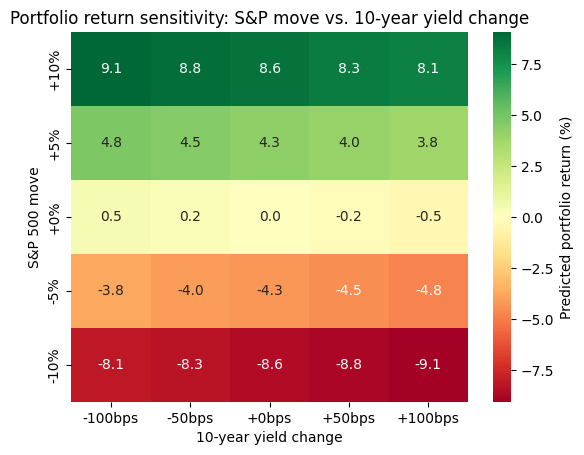

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(matrix.iloc[::-1] , annot=True, fmt=".1f", cmap="RdYlGn", center=0, #matrix.iloc[::-1] has you step backwards one at a time
            cbar_kws={"label": "Predicted portfolio return (%)"})
plt.title("Portfolio return sensitivity: S&P move vs. 10-year yield change")
plt.ylabel("S&P 500 move")
plt.xlabel("10-year yield change")
plt.show()